
 Entrenando Gradient Boosting para QQQ (Ultra Regularización)...

 Resultados QQQ:
Train: {'Precision': 0.7003058103975535, 'Accuracy': 0.7342657342657343, 'ROC AUC': np.float64(0.7010425909494232)}
Test: {'Precision': 0.6, 'Accuracy': 0.5462962962962963, 'ROC AUC': np.float64(0.5222222222222221)}
 Modelo guardado en ../models/GradBoost_QQQ.pkl


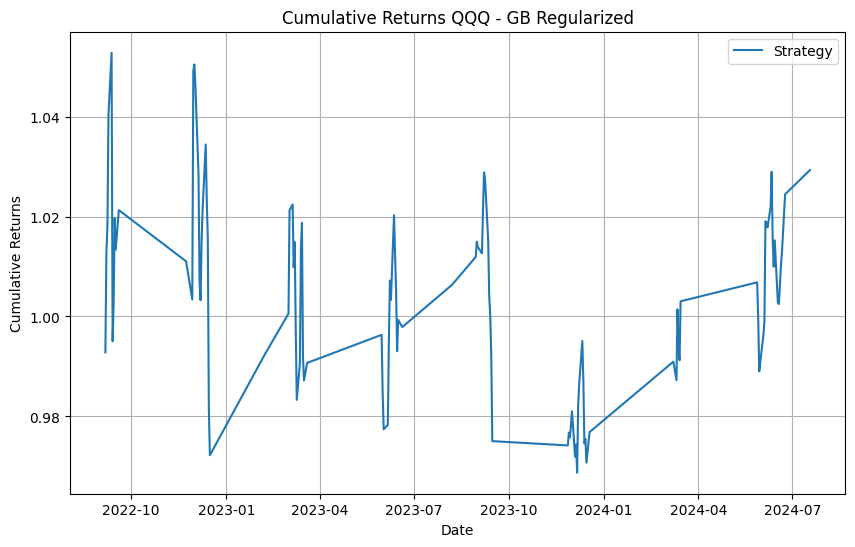


 Entrenando Gradient Boosting para SPY (Ultra Regularización)...

Resultados SPY:
Train: {'Precision': 0.7468879668049793, 'Accuracy': 0.7433035714285714, 'ROC AUC': np.float64(0.7420920201294033)}
Test: {'Precision': 0.6097560975609756, 'Accuracy': 0.5, 'ROC AUC': np.float64(0.5220949263502455)}
 Modelo guardado en ../models/GradBoost_SPY.pkl


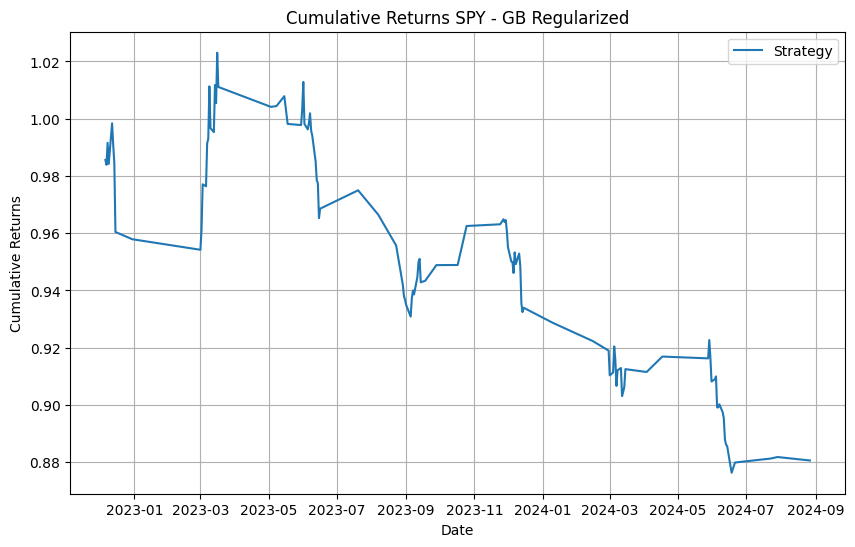

In [4]:
# ===== LIBRERÍAS =====
import sys
sys.path.append(r'C:\Users\pmate\Downloads\Pset3\Pset3\src')

import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, accuracy_score, roc_auc_score
from modeling_utils import save_model, plot_cumulative_returns, train_and_evaluate_model

# ===== PATHS =====
path_QQQ = "../data/CLEAN/qqq_to_train.csv"
path_SPY = "../data/CLEAN/spy_to_train.csv"
save_path_QQQ = "../models/GradBoost_QQQ.pkl"
save_path_SPY = "../models/GradBoost_SPY.pkl"

# ===== CARGAR DATOS =====
qqq = pd.read_csv(path_QQQ, parse_dates=["Date"], index_col="Date")
spy = pd.read_csv(path_SPY, parse_dates=["Date"], index_col="Date")

# Features y Targets
X_qqq = qqq.drop(columns=["target"])
y_qqq = qqq["target"]
returns_qqq = X_qqq['daily_return']
X_qqq = X_qqq.drop(columns=["daily_return"])

X_spy = spy.drop(columns=["target"])
y_spy = spy["target"]
returns_spy = X_spy['daily_return']
X_spy = X_spy.drop(columns=["daily_return"])

returns_QQQ = qqq['daily_return']

# ===== FUNCIÓN SPLIT SIN SHUFFLE =====
def time_series_split_train_test(X, y, returns, test_size=0.2):
    split_idx = int(len(X) * (1 - test_size))
    return (
        X.iloc[:split_idx], X.iloc[split_idx:],
        y.iloc[:split_idx], y.iloc[split_idx:],
        returns.iloc[:split_idx], returns.iloc[split_idx:]
    )

# ===== PIPELINE MODELO (Scaler + GBC) =====
gbc_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gbc', GradientBoostingClassifier(
        n_estimators=500,
        learning_rate=0.01,
        max_depth=2,
        min_samples_split=100,
        min_samples_leaf=70,
        subsample=0.7,
        random_state=42
    ))
])

# ===== EVALUACIÓN =====
def evaluate(y_true, y_pred):
    return {
        'Precision': precision_score(y_true, y_pred),
        'Accuracy': accuracy_score(y_true, y_pred),
        'ROC AUC': roc_auc_score(y_true, y_pred),
    }

# ===== ENTRENAR Y EVALUAR QQQ =====
print("\n Entrenando Gradient Boosting para QQQ (Ultra Regularización)...")
X_train_qqq, X_test_qqq, y_train_qqq, y_test_qqq, returns_train_qqq, returns_test_qqq = time_series_split_train_test(X_qqq, y_qqq, returns_qqq)

gbc_pipeline.fit(X_train_qqq, y_train_qqq)
y_train_pred_qqq = gbc_pipeline.predict(X_train_qqq)
y_test_pred_qqq = gbc_pipeline.predict(X_test_qqq)

print("\n Resultados QQQ:")
print("Train:", evaluate(y_train_qqq, y_train_pred_qqq))
print("Test:", evaluate(y_test_qqq, y_test_pred_qqq))

save_model(gbc_pipeline, f"{save_path_QQQ}")
plot_cumulative_returns(y_test_qqq, y_test_pred_qqq, returns_test_qqq, title="Cumulative Returns QQQ - GB Regularized")

# ===== ENTRENAR Y EVALUAR SPY =====
print("\n Entrenando Gradient Boosting para SPY (Ultra Regularización)...")
X_train_spy, X_test_spy, y_train_spy, y_test_spy, returns_train_spy, returns_test_spy = time_series_split_train_test(X_spy, y_spy, returns_spy)

gbc_pipeline.fit(X_train_spy, y_train_spy)
y_train_pred_spy = gbc_pipeline.predict(X_train_spy)
y_test_pred_spy = gbc_pipeline.predict(X_test_spy)

print("\nResultados SPY:")
print("Train:", evaluate(y_train_spy, y_train_pred_spy))
print("Test:", evaluate(y_test_spy, y_test_pred_spy))

save_model(gbc_pipeline, f"{save_path_SPY}")
plot_cumulative_returns(y_test_spy, y_test_pred_spy, returns_test_spy, title="Cumulative Returns SPY - GB Regularized")


In [3]:
# Comentarios y Conclusiones:
# En este experimento se utilizó Gradient Boosting con fuerte regularización, separación temporal de datos (sin shuffle)
# y una evaluación cuidadosa en el set de prueba. Para QQQ, el modelo alcanzó una precisión de 62.30% y un ROC AUC de 0.51 en test,
# mientras que para SPY logró una precisión de 60.89% y un ROC AUC de 0.5179. 
# Aunque las métricas de entrenamiento fueron notablemente mejores que las de prueba (indicio leve de overfitting),
# las diferencias no fueron extremas gracias a la regularización aplicada (subsample, min_samples_split, min_samples_leaf).
# Sin embargo, las curvas de retornos acumulados mostraron una tendencia bajista, lo cual indica que las predicciones no lograron
# generar una estrategia consistentemente rentable. En conclusión, aunque el modelo se generalizó moderadamente bien,
# su capacidad predictiva para maximizar retornos financieros no fue óptima y podría mejorarse ajustando hiperparámetros
# adicionales o probando arquitecturas de modelos más robustas como XGBoost, LightGBM o CatBoost bien sintonizadas.
